# Epsilon vs N for EVO_SIM

This notebook compares how the collective-posterior inference quality changes as we vary:

- the log-floor `epsilon`
- the number of replicates `N`

The benchmark uses the first 100 cases from `theta_test.pt` and `x_test_r.pt`. For each case and each `N in {3, 5, 7, 10}`, it samples a random subset of `N` replicates from the available 10 benchmark replicates.


In [2]:
from pathlib import Path
import pickle
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from tqdm.auto import tqdm

sys.path.insert(1, '..')

from collective_posterior import CollectivePosterior
from inference_utils import get_prior

plt.rcParams['figure.dpi'] = 110
sns.set_context('notebook')
torch.set_grad_enabled(False)

import matplotlib
def change_font(fontsize):
    matplotlib.rcParams['xtick.labelsize'] = fontsize
    matplotlib.rcParams['ytick.labelsize'] = fontsize
    matplotlib.rcParams['font.size'] = fontsize
change_font(20)

/home/jupyter-nadavbennun/.conda/envs/npse/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Setup

The defaults below are meant to make the sweep practical in a notebook while still using the new adaptive SIR sampler.
If you want a more expensive final run, increase `N_DRAWS` and `N_FINAL`.


In [3]:
BASE = Path('.')
MODEL = 'EVO_SIM'

N_CASES = 100
N_REPS_LIST = [3, 5, 7, 10]
EPSILON_GRID = [10.0, 0.0, -3.0, -10.0, -30.0, -100.0, -300.0, -1000.0]
CONF_LEVELS = torch.tensor([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95], dtype=torch.float32)

N_DRAWS = 100_000
N_FINAL = 10_000
OVERSAMPLE = 2.0
JITTER_SCALE = 0.15
ESS_MIN_FRAC = 1e-3
MAX_ATTEMPTS = 3
RNG_SEED = 0

RESULTS_PATH = BASE / 'epsilon_vs_N_results_full.pt'

prior = get_prior(MODEL)
posterior = pickle.load(open(BASE / 'posterior_EVO_SIM_30000_20.pkl', 'rb'))

theta_test = torch.load(BASE / 'theta_test.pt')[:N_CASES].to(torch.float32)
x_test = torch.load(BASE / 'x_test_r.pt')[:N_CASES].to(torch.float32)

if max(N_REPS_LIST) > x_test.shape[1]:
    raise ValueError(f'N_REPS_LIST asks for {max(N_REPS_LIST)} replicates, but x_test only has {x_test.shape[1]}.')

PARAM_LABELS = ['s1', 's2', 's3', 'u1', 'u2', 'u3']
if len(PARAM_LABELS) != theta_test.shape[1]:
    PARAM_LABELS = [f'param_{i}' for i in range(theta_test.shape[1])]

rng = np.random.default_rng(RNG_SEED)
replicate_index_map = {
    n_reps: torch.tensor(
        np.stack([rng.choice(x_test.shape[1], size=n_reps, replace=False) for _ in range(N_CASES)]),
        dtype=torch.long,
    )
    for n_reps in N_REPS_LIST
}

if hasattr(prior, 'base_dist') and hasattr(prior.base_dist, 'low'):
    prior_low = prior.base_dist.low.to(torch.float32)
    prior_high = prior.base_dist.high.to(torch.float32)
else:
    prior_low = prior.low.to(torch.float32)
    prior_high = prior.high.to(torch.float32)
prior_width = prior_high - prior_low

pd.DataFrame({
    'setting': ['n_cases', 'N_reps', 'epsilon_grid', 'n_draws', 'n_final', 'ess_min_frac', 'rng_seed', 'test_tensor', 'parameter_labels'],
    'value': [N_CASES, str(N_REPS_LIST), str(EPSILON_GRID), N_DRAWS, N_FINAL, ESS_MIN_FRAC, RNG_SEED, 'x_test_r.pt', ', '.join(PARAM_LABELS)],
})


/tmp/ipykernel_2587578/1295929488.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  theta_test = torch.load(BASE / 'theta_test.pt')[:N_CASES].to(torch.float32)
/tmp/ipyke

,setting,value
0,n_cases,100
1,N_reps,"[3, 5, 7, 10]"
2,epsilon_grid,"[10.0, 0.0, -3.0, -10.0, -30.0, -100.0, -300.0..."
3,n_draws,100000
4,n_final,10000
5,ess_min_frac,0.001
6,rng_seed,0
7,test_tensor,x_test_r.pt
8,parameter_labels,"s1, s2, s3, u1, u2, u3"


## Helpers

Inference quality is summarized in two ways:

- `mean_nmae`: mean normalized absolute error of the posterior mean, normalized by prior width
- `coverage_mae_per_param`: per-parameter mean absolute deviation between empirical coverage and the nominal confidence level
- `coverage_mae_mean`: mean of the per-parameter coverage errors, used only as a compact aggregate


In [4]:
def coverage_tensor(samples, theta, conf_levels=CONF_LEVELS):
    covs = torch.empty(len(conf_levels), len(theta), dtype=torch.float32)
    for j, conf_level in enumerate(conf_levels):
        alpha = (1 - float(conf_level)) / 2
        hdi_low = torch.quantile(samples, alpha, dim=0)
        hdi_high = torch.quantile(samples, 1 - alpha, dim=0)
        covs[j] = ((theta > hdi_low) * (theta < hdi_high)).to(torch.float32)
    return covs


def summarize_setting(accus, covs, conf_levels=CONF_LEVELS):
    normalized_abs_error = accus.abs() / prior_width
    nmae_per_case = normalized_abs_error.mean(dim=1)
    mean_nmae = float(nmae_per_case.mean())
    sd_nmae = float(nmae_per_case.std(unbiased=False))

    coverage_curve_per_param = covs.float().mean(dim=0)
    nominal = conf_levels[:, None]
    coverage_mae_per_param = (coverage_curve_per_param - nominal).abs().mean(dim=0)
    coverage_mae_90_per_param = (coverage_curve_per_param[8] - conf_levels[8]).abs()
    coverage_curve_mean = coverage_curve_per_param.mean(dim=1)
    coverage_mae_mean = float(coverage_mae_per_param.mean())
    coverage_mae_90_mean = float(coverage_mae_90_per_param.mean())

    return {
        'mean_nmae': mean_nmae,
        'sd_nmae': sd_nmae,
        'coverage_mae_mean': coverage_mae_mean,
        'coverage_mae_90_mean': coverage_mae_90_mean,
        'coverage_curve_mean': coverage_curve_mean.cpu(),
        'coverage_mae_per_param': coverage_mae_per_param.cpu(),
        'coverage_mae_90_per_param': coverage_mae_90_per_param.cpu(),
        'coverage_curve_per_param': coverage_curve_per_param.cpu(),
        'mean_abs_error_per_param': normalized_abs_error.mean(dim=0).cpu(),
        # Back-compatible aggregate aliases, now derived from per-parameter summaries.
        'coverage_mae': coverage_mae_mean,
        'coverage_mae_90': coverage_mae_90_mean,
        'coverage_curve': coverage_curve_mean.cpu(),
    }


def evaluate_setting(epsilon, n_reps, *, n_draws=N_DRAWS, n_final=N_FINAL):
    start = time.time()
    accus = torch.empty((N_CASES, theta_test.shape[1]), dtype=torch.float32)
    covs = torch.empty((N_CASES, len(CONF_LEVELS), theta_test.shape[1]), dtype=torch.float32)

    desc = f'N={n_reps}, epsilon={epsilon:g}'
    for i in tqdm(range(N_CASES), desc=desc):
        theta = theta_test[i]
        rep_idx = replicate_index_map[n_reps][i]
        Xs = x_test[i, rep_idx]
        cp = CollectivePosterior(prior, Xs=Xs, amortized_posterior=posterior, log_C=1, epsilon=float(epsilon))
        samples = cp.adaptive_sir(
            n_draws=n_draws,
            n_final=n_final,
            ess_min_frac=ESS_MIN_FRAC,
            oversample=OVERSAMPLE,
            jitter_scale=JITTER_SCALE,
            max_attempts=MAX_ATTEMPTS,
            keep=False,
        )
        accus[i] = samples.mean(dim=0) - theta
        covs[i] = coverage_tensor(samples, theta)

    summary = summarize_setting(accus, covs)
    summary.update({
        'epsilon': float(epsilon),
        'n_reps': int(n_reps),
        'runtime_sec': float(time.time() - start),
        'accus': accus.cpu(),
        'covs': covs.cpu(),
    })
    return summary


## Estimated Epsilon Distributions On The Test Set

This diagnostic estimates `epsilon` directly from the collective-posterior replicate sets used in the benchmark.
For each case, each `N in {3, 5, 7, 10}`, and each quantile in `{0.8, 0.95, 0.99}`, it runs `estimate_epsilon(..., n_reps=20)` and stores the resulting log-floor estimate.

The estimates are cached so you can rerun the plot without recomputing them.


In [5]:
EPSILON_QUANTILES = [0.8, 0.95, 0.99]
EPSILON_ESTIMATE_REPS = 20
EPSILON_EST_PATH = BASE / 'epsilon_testset_estimates_full.pt'

if EPSILON_EST_PATH.exists():
    epsilon_est_cache = torch.load(EPSILON_EST_PATH)
else:
    epsilon_est_cache = {}

estimate_rows = []
for n_reps in N_REPS_LIST:
    for quant in EPSILON_QUANTILES:
        key = (int(n_reps), float(quant))
        if key not in epsilon_est_cache:
            estimates = []
            for i in tqdm(range(N_CASES), desc=f'epsilon estimates: N={n_reps}, q={quant:g}'):
                rep_idx = replicate_index_map[n_reps][i]
                Xs = x_test[i, rep_idx]
                cp = CollectivePosterior(prior, Xs=Xs, amortized_posterior=posterior, log_C=1, epsilon=-1000.0)
                eps_hat = cp.estimate_epsilon(Xs, quant=quant, n_reps=EPSILON_ESTIMATE_REPS)[0].item()
                estimates.append(float(eps_hat))
            epsilon_est_cache[key] = torch.tensor(estimates, dtype=torch.float32)
            torch.save(epsilon_est_cache, EPSILON_EST_PATH)
        for value in epsilon_est_cache[key].tolist():
            estimate_rows.append({
                'n_reps': int(n_reps),
                'quantile': float(quant),
                'epsilon_hat': float(value),
            })

epsilon_est_df = pd.DataFrame(estimate_rows)
display(epsilon_est_df.groupby(['n_reps', 'quantile'])['epsilon_hat'].describe())



/tmp/ipykernel_2587578/4028291437.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  epsilon_est_cache = torch.load(EPSILON_EST_PATH)


count       mean        std         min        25%  \
n_reps quantile                                                       
3      0.80      100.0 -65.512952  57.430199 -325.352631 -85.146986   
       0.95      100.0 -24.563143  19.122716  -91.778152 -32.025928   
       0.99      100.0 -11.366248   9.392840  -57.962158 -14.830767   
5      0.80      100.0 -57.734590  44.758937 -293.645172 -78.300200   
       0.95      100.0 -21.863013  14.965818  -68.656631 -29.139875   
       0.99      100.0  -9.491981   6.038464  -27.075094 -12.977332   
7      0.80      100.0 -56.909101  40.972194 -242.516846 -79.889233   
       0.95      100.0 -20.940890  13.938090  -64.822067 -28.837838   
       0.99      100.0  -8.895811   5.495821  -25.741032 -12.660112   
10     0.80      100.0 -55.396542  38.437015 -253.854767 -71.431625   
       0.95      100.0 -20.394454  13.094367  -63.392414 -28.399553   
       0.99      100.0  -8.696969   5.426188  -29.910629 -11.624777   

                       50%        75%        max  
n_reps quantile                                   
3      0.80     -46.363474 -27.300336  -8.944708  
       0.95     -18.339514 -10.719063  -4.681996  
       0.99      -7.601701  -4.774446  -3.256896  
5      0.80     -43.110292 -24.752258 -10.566266  
       0.95     -17.714648  -9.440598  -4.957156  
       0.99      -7.584988  -4.353772  -3.345765  
7      0.80     -44.163490 -24.722440 -10.425933  
       0.95     -17.325119  -9.421125  -4.829465  
       0.99      -6.899181  -4.338553  -3.321402  
10     0.80     -45.363058 -26.136936  -9.882768  
       0.95     -17.454230  -9.915769  -4.780709  
       0.99      -7.051702  -4.408205  -3.314386

/tmp/ipykernel_2587578/3179999712.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_2587578/3179999712.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_2587578/3179999712.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_2587578/3179999712.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


Text(0.02, 0.5, 'estimated $log_{10}(\\varepsilon)$')

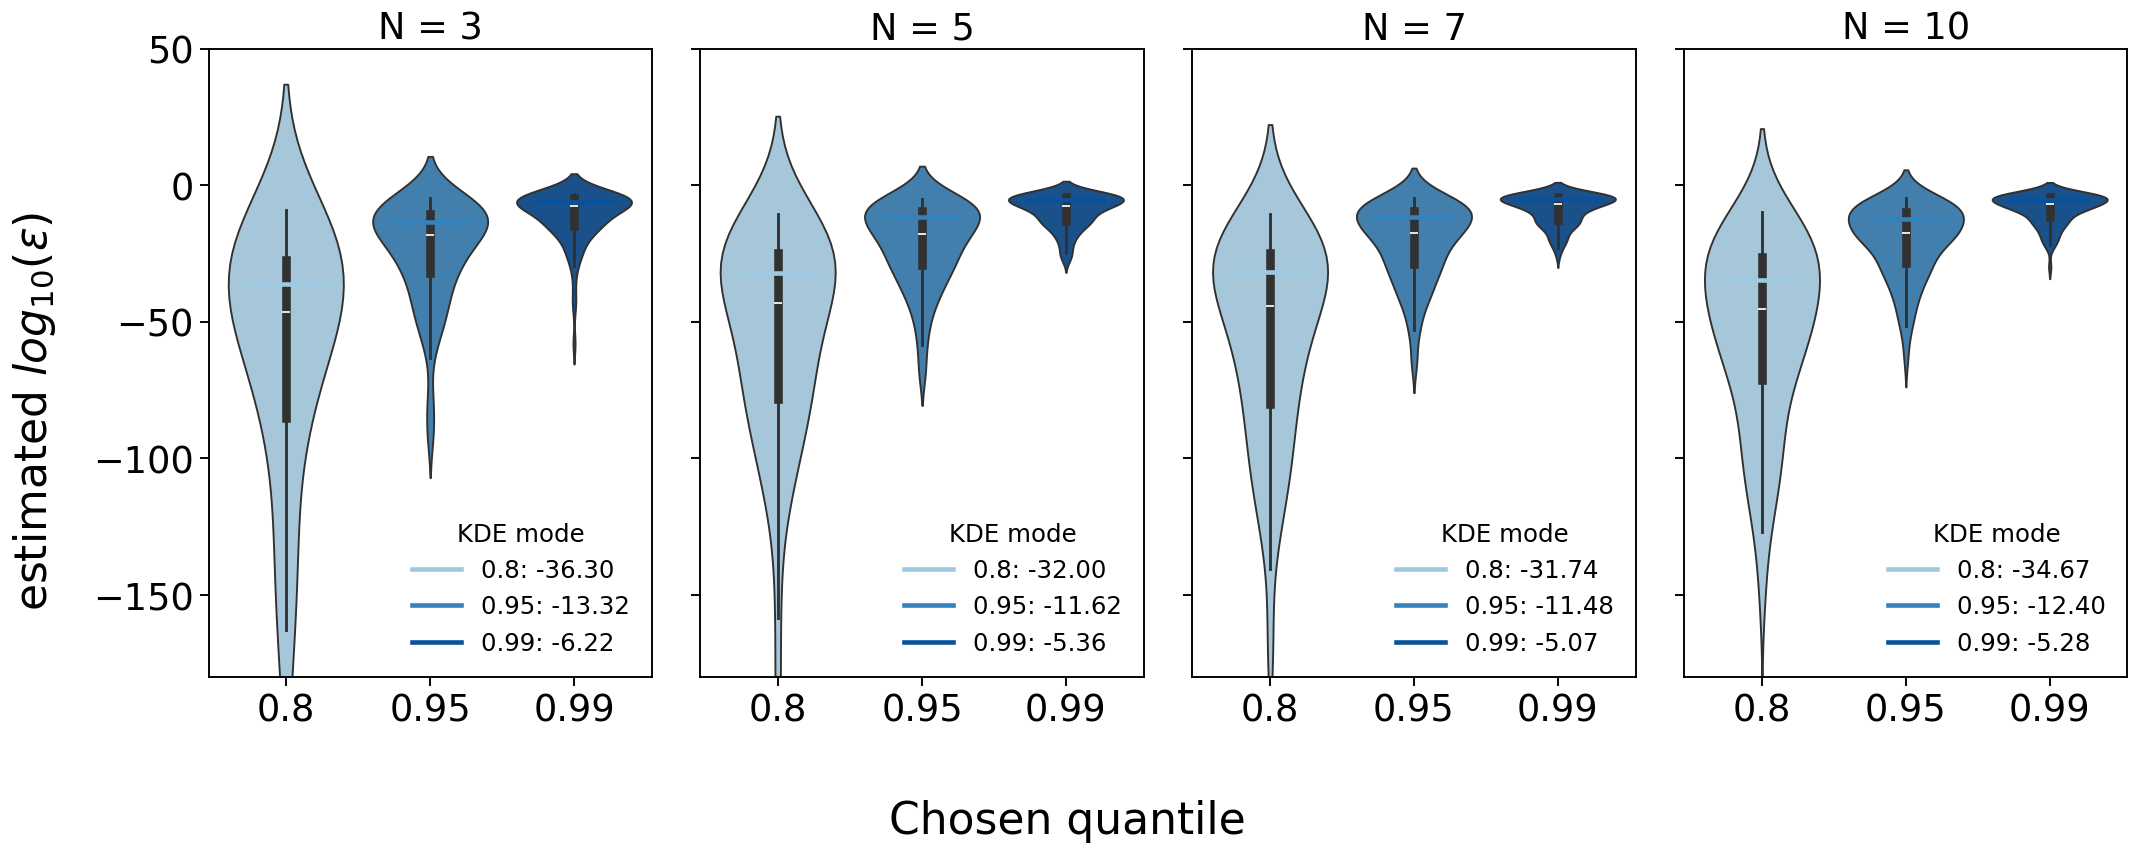

In [6]:
change_font(24)
fig, axes = plt.subplots(1, len(N_REPS_LIST), figsize=(5 * len(N_REPS_LIST), 8), sharey=True, tight_layout=True)
if len(N_REPS_LIST) == 1:
    axes = [axes]

palette = {'0.8': '#9ecae1', '0.95': '#3182bd', '0.99': '#08519c'}
quantile_labels = [f'{q:g}' for q in EPSILON_QUANTILES]

def kde_mode(values, gridsize=2048):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return np.nan
    if len(values) == 1 or np.allclose(values.min(), values.max()):
        return float(values[0])
    from scipy.stats import gaussian_kde
    grid = np.linspace(values.min(), values.max(), gridsize)
    density = gaussian_kde(values)(grid)
    return float(grid[np.argmax(density)])

for ax, n_reps in zip(axes, N_REPS_LIST):
    subset = epsilon_est_df[epsilon_est_df['n_reps'] == n_reps].copy()
    subset['quantile_label'] = pd.Categorical(
        subset['quantile'].map(lambda q: f'{q:g}'),
        categories=quantile_labels,
        ordered=True,
    )
    sns.violinplot(
        data=subset,
        x='quantile_label',
        y='epsilon_hat',
        palette=palette,
        ax=ax,
    )

    legend_handles = []
    for xpos, q_label in enumerate(quantile_labels):
        q_subset = subset[subset['quantile_label'] == q_label]['epsilon_hat']
        mode_est = kde_mode(q_subset.to_numpy())
        

        ax.hlines(mode_est, xpos - 0.28, xpos + 0.28, color=palette[q_label], lw=3)
        legend_handles.append(
            plt.Line2D([0], [0], color=palette[q_label], lw=3, label=f'{q_label}: {mode_est:.2f}')
        )

    ax.legend(handles=legend_handles, title='KDE mode', frameon=False, loc='lower right', fontsize=16, title_fontsize=16)
    ax.set_title(f'N = {n_reps}', fontsize=24)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_ylim(-180, 50)
fig.supxlabel('Chosen quantile')
fig.supylabel('estimated $log_{10}(\\varepsilon)$')


## Run The Sweep

The loop caches each `(epsilon, N)` result to `epsilon_vs_N_results.pt`, so interrupted runs can be resumed.


In [7]:
if RESULTS_PATH.exists():
    cache = torch.load(RESULTS_PATH)
else:
    cache = {}

cache_dirty = False
for key, cached_result in list(cache.items()):
    if 'accus' in cached_result and 'covs' in cached_result:
        needs_param_coverage = (
            'coverage_curve_per_param' not in cached_result
            or 'coverage_mae_per_param' not in cached_result
        )
        if needs_param_coverage:
            cached_result.update(summarize_setting(cached_result['accus'], cached_result['covs']))
            cache_dirty = True

results = []
for n_reps in N_REPS_LIST:
    for epsilon in EPSILON_GRID:
        key = (int(n_reps), float(epsilon))
        if key not in cache:
            cache[key] = evaluate_setting(epsilon=epsilon, n_reps=n_reps)
            torch.save(cache, RESULTS_PATH)
        results.append(cache[key])

if cache_dirty:
    torch.save(cache, RESULTS_PATH)

results_df = pd.DataFrame([
    {
        'n_reps': r['n_reps'],
        'epsilon': r['epsilon'],
        'mean_nmae': r['mean_nmae'],
        'sd_nmae': r['sd_nmae'],
        'coverage_mae_mean': r['coverage_mae_mean'] if 'coverage_mae_mean' in r else r['coverage_mae'],
        'coverage_mae_90_mean': r['coverage_mae_90_mean'] if 'coverage_mae_90_mean' in r else r['coverage_mae_90'],
        'runtime_sec': r['runtime_sec'],
    }
    for r in results
]).sort_values(['n_reps', 'epsilon']).reset_index(drop=True)

coverage_param_df = pd.DataFrame([
    {
        'n_reps': r['n_reps'],
        'epsilon': r['epsilon'],
        'param': param_idx,
        'param_label': param_label,
        'coverage_mae': float(r['coverage_mae_per_param'][param_idx]),
        'coverage_mae_90': float(r['coverage_mae_90_per_param'][param_idx]),
        'coverage_at_90': float(r['coverage_curve_per_param'][8, param_idx]),
        'mean_nmae_param': float(r['mean_abs_error_per_param'][param_idx]),
        'runtime_sec': r['runtime_sec'],
    }
    for r in results
    for param_idx, param_label in enumerate(PARAM_LABELS)
]).sort_values(['n_reps', 'param', 'epsilon']).reset_index(drop=True)

display(results_df)
coverage_param_df


/tmp/ipykernel_2587578/3912342858.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cache = torch.load(RESULTS_PATH)


,n_reps,epsilon,mean_nmae,sd_nmae,coverage_mae_mean,coverage_mae_90_mean,runtime_sec
0,3,-1000.0,0.160548,0.075612,0.205167,0.321667,91.477180
1,3,-300.0,0.161167,0.076437,0.206833,0.330000,93.929335
2,3,-100.0,0.148410,0.069316,0.174667,0.286667,91.317664
3,3,-30.0,0.129446,0.060142,0.141167,0.215000,90.538281
4,3,-10.0,0.124883,0.054513,0.074333,0.128333,93.492571
5,3,-3.0,0.204334,0.055887,0.048333,0.025000,92.906102
6,3,0.0,0.237935,0.054917,0.044667,0.023333,90.786879
7,3,10.0,0.248246,0.055684,0.041667,0.023333,91.018899
8,5,-1000.0,0.165344,0.078333,0.196000,0.321667,139.570785
9,5,-300.0,0.164482,0.077152,0.199500,0.318333,141.257990


,n_reps,epsilon,param,param_label,coverage_mae,coverage_mae_90,coverage_at_90,mean_nmae_param,runtime_sec
0,3,-1000.0,0,s1,0.292,0.49,0.41,0.186753,91.477180
1,3,-300.0,0,s1,0.286,0.46,0.44,0.187048,93.929335
2,3,-100.0,0,s1,0.264,0.45,0.45,0.166411,91.317664
3,3,-30.0,0,s1,0.242,0.34,0.56,0.151128,90.538281
4,3,-10.0,0,s1,0.124,0.23,0.67,0.147234,93.492571
...,...,...,...,...,...,...,...,...,...
187,10,-30.0,5,u3,0.024,0.02,0.88,0.093816,231.353771
188,10,-10.0,5,u3,0.044,0.02,0.88,0.088446,272.457925
189,10,-3.0,5,u3,0.090,0.04,0.94,0.108253,265.589065
190,10,0.0,5,u3,0.091,0.06,0.96,0.185224,271.973412


## Heatmaps

Lower is better in all panels below.


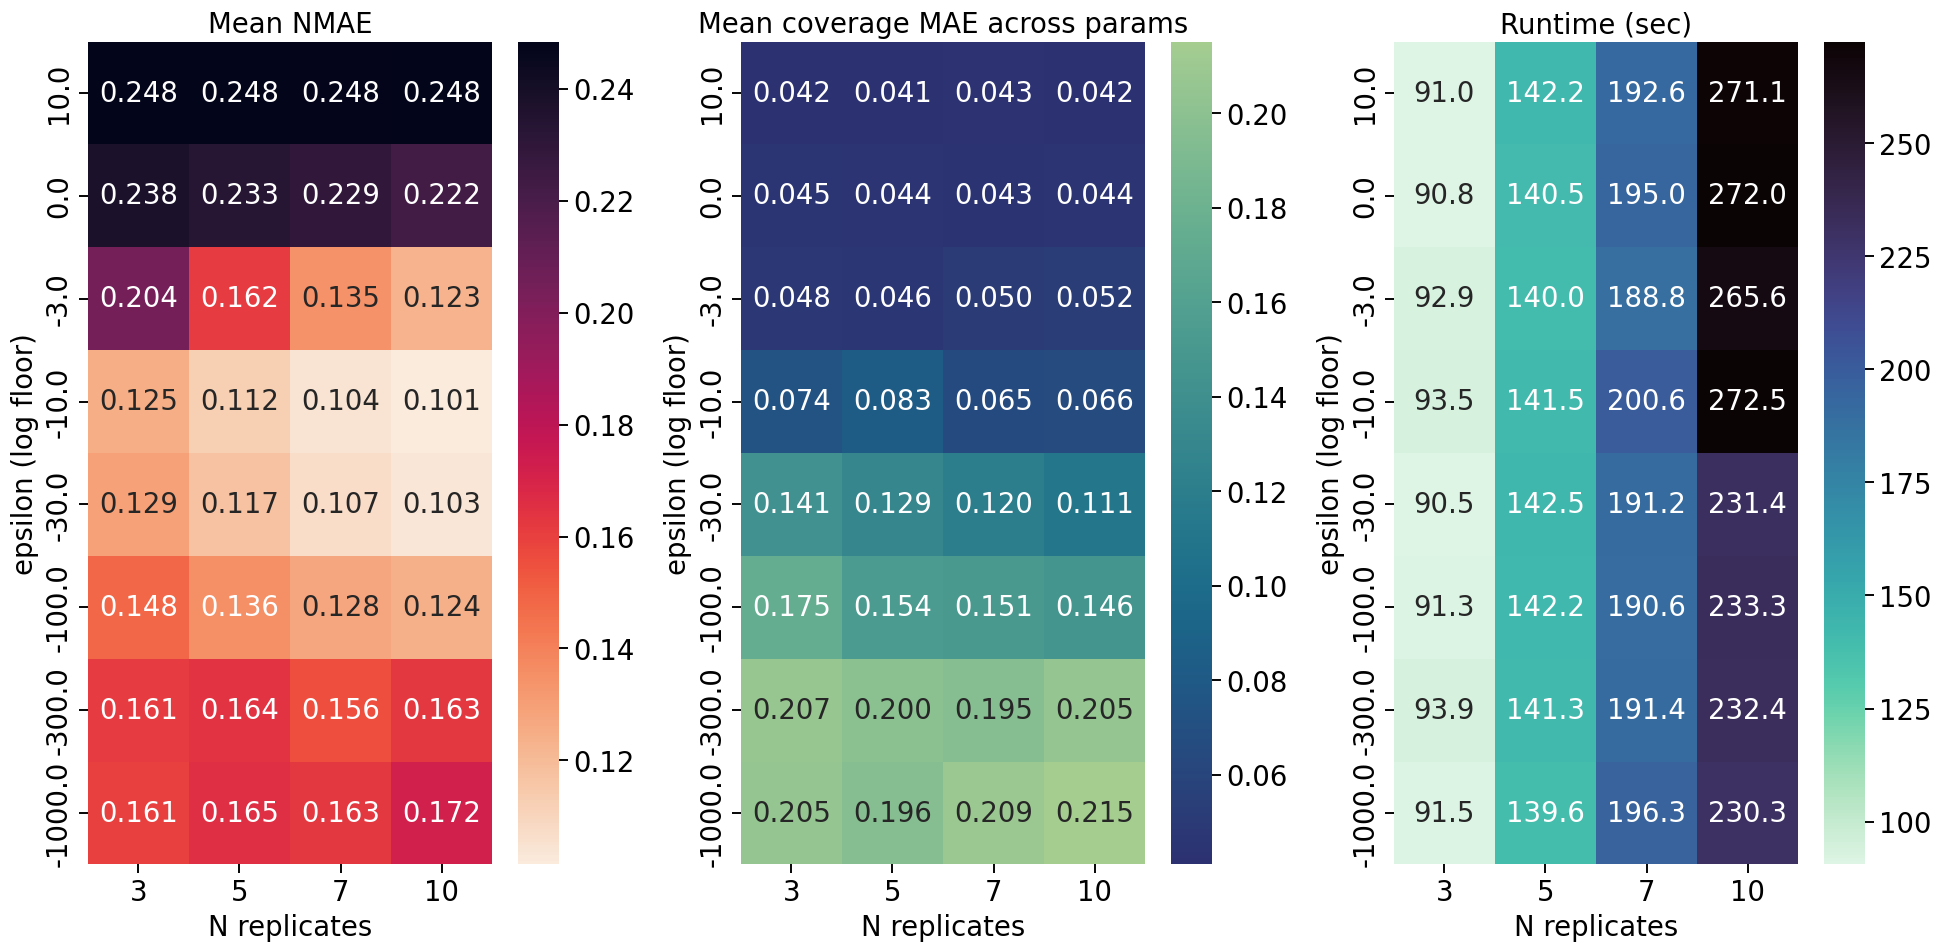

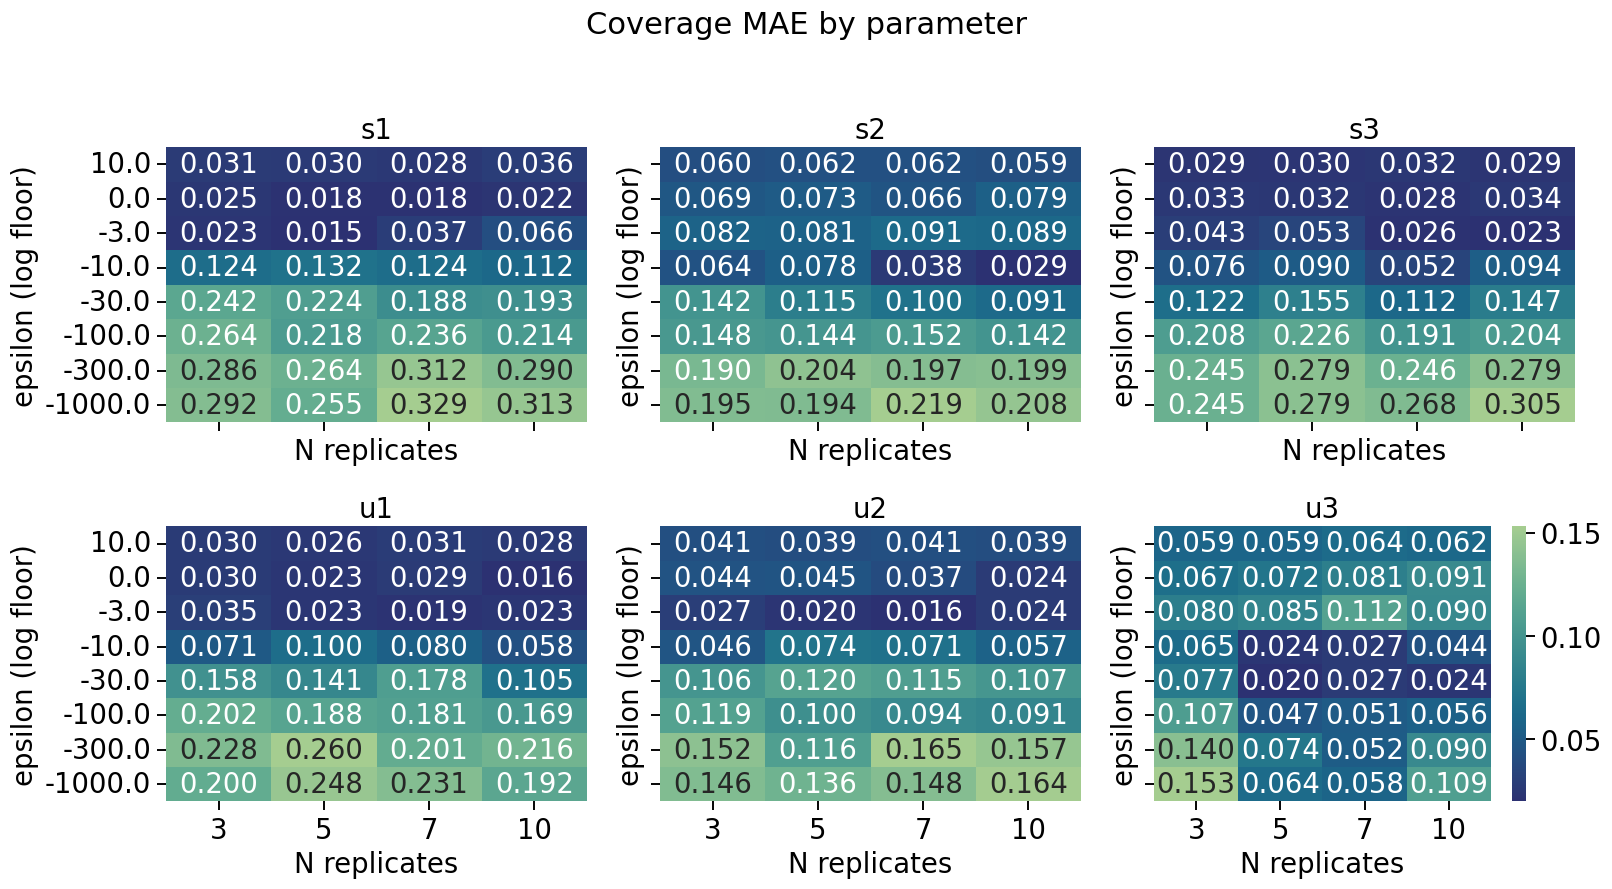

In [8]:
change_font(18)
fig, axes = plt.subplots(1, 3, figsize=(18, 9), tight_layout=True)

pivot_nmae = results_df.pivot(index='epsilon', columns='n_reps', values='mean_nmae').sort_index(ascending=False)
pivot_cov_mean = results_df.pivot(index='epsilon', columns='n_reps', values='coverage_mae_mean').sort_index(ascending=False)
pivot_time = results_df.pivot(index='epsilon', columns='n_reps', values='runtime_sec').sort_index(ascending=False)

sns.heatmap(pivot_nmae, annot=True, fmt='.3f', cmap='rocket_r', ax=axes[0])
axes[0].set_title('Mean NMAE', fontsize=18)
axes[0].set_xlabel('N replicates', fontsize=18)
axes[0].set_ylabel('epsilon (log floor)', fontsize=18)

sns.heatmap(pivot_cov_mean, annot=True, fmt='.3f', cmap='crest_r', ax=axes[1])
axes[1].set_title('Mean coverage MAE across params', fontsize=18)
axes[1].set_xlabel('N replicates', fontsize=18)
axes[1].set_ylabel('epsilon (log floor)', fontsize=18)

sns.heatmap(pivot_time, annot=True, fmt='.1f', cmap='mako_r', ax=axes[2])
axes[2].set_title('Runtime (sec)', fontsize=18)
axes[2].set_xlabel('N replicates', fontsize=18)
axes[2].set_ylabel('epsilon (log floor)', fontsize=18)

fig.savefig(BASE / 'epsilon_vs_N_heatmaps.png', dpi=300)
plt.show()

n_params = len(PARAM_LABELS)
n_cols = min(3, n_params)
n_rows = int(np.ceil(n_params / n_cols))
fig_cov, axes_cov = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharex=True, sharey=True, tight_layout=True)
axes_cov = np.asarray(axes_cov).reshape(-1)
for idx, (ax, param_label) in enumerate(zip(axes_cov, PARAM_LABELS)):
    subset = coverage_param_df[coverage_param_df['param_label'] == param_label]
    pivot_cov = subset.pivot(index='epsilon', columns='n_reps', values='coverage_mae').sort_index(ascending=False)
    sns.heatmap(pivot_cov, annot=True, fmt='.3f', cmap='crest_r', ax=ax, cbar=(idx == n_params - 1))
    ax.set_title(param_label, fontsize=18)
    ax.set_xlabel('N replicates', fontsize=18)
    ax.set_ylabel('epsilon (log floor)', fontsize=18)

for ax in axes_cov[n_params:]:
    ax.axis('off')

fig_cov.suptitle('Coverage MAE by parameter', fontsize=20, y=1.02)
fig_cov.savefig(BASE / 'epsilon_vs_N_param_coverage_heatmaps.png', dpi=300, bbox_inches='tight')
plt.show()


## Line Summaries

These plots make it easier to see whether the preferred `epsilon` shifts as `N` increases.
The coverage panel summarizes all parameters together: each vertical bar spans the lowest-to-highest parameter-wise coverage MAE for one `(epsilon, N)`, and the marker shows the mean across parameters.


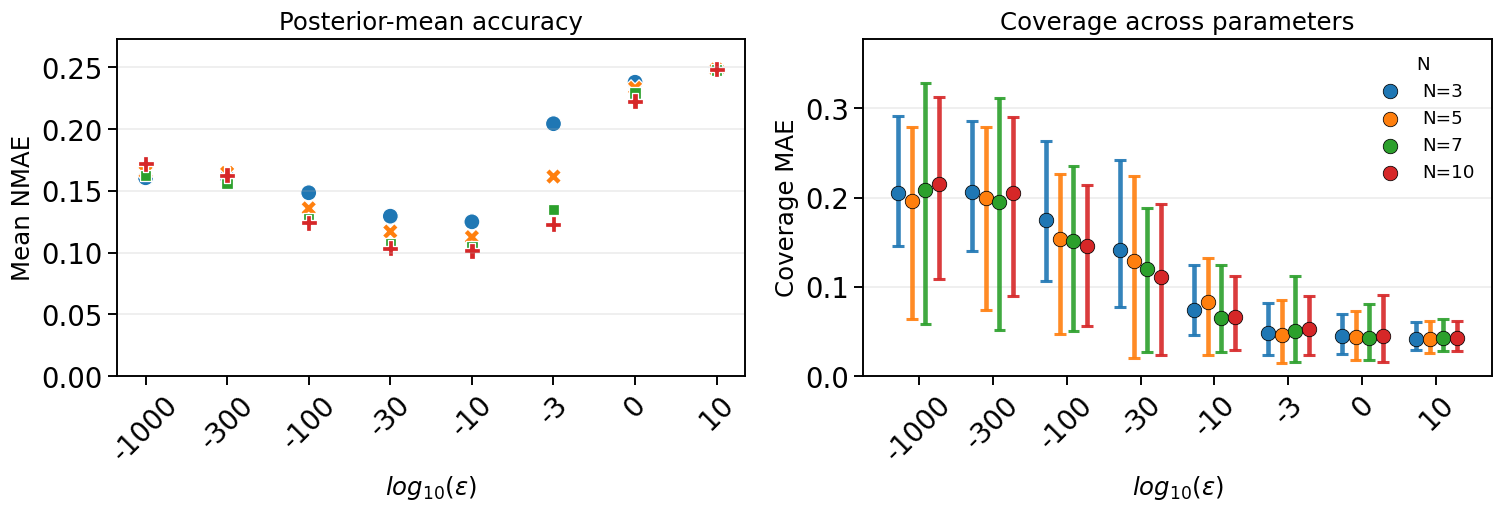

In [13]:
epsilon_order = [-1000.0, -300.0, -100.0, -30.0, -10.0, -3.0, 0.0, 10.0]
epsilon_labels = [f'{x:g}' for x in epsilon_order]
n_palette = dict(zip(N_REPS_LIST, sns.color_palette('tab10', n_colors=len(N_REPS_LIST))))

plot_df = results_df.copy()
plot_df['epsilon_label'] = pd.Categorical(
    plot_df['epsilon'].map(lambda x: f'{x:g}'),
    categories=epsilon_labels,
    ordered=True,
)

coverage_plot_df = coverage_param_df.copy()
coverage_summary_df = (
    coverage_plot_df
    .groupby(['n_reps', 'epsilon'], as_index=False)
    .agg(
        coverage_mae_mean=('coverage_mae', 'mean'),
        coverage_mae_min=('coverage_mae', 'min'),
        coverage_mae_max=('coverage_mae', 'max'),
    )
)
coverage_summary_df['epsilon_label'] = coverage_summary_df['epsilon'].map(lambda x: f'{x:g}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5), tight_layout=True)

sns.scatterplot(
    data=plot_df,
    x='epsilon_label',
    y='mean_nmae',
    hue='n_reps',
    style='n_reps',
    s=110,
    palette=n_palette,
    ax=axes[0],
    legend=False,
)
axes[0].set_title('Posterior-mean accuracy', fontsize=16)
axes[0].set_ylabel('Mean NMAE', fontsize=16)
axes[0].set_xlabel('$log_{10}(\\varepsilon)$', fontsize=16)
axes[0].grid(axis='y', alpha=0.25)
axes[0].set_ylim(0, plot_df['mean_nmae'].max() * 1.1)
axes[0].tick_params(axis='x', rotation=45)

x = np.arange(len(epsilon_labels), dtype=float)
offsets = np.linspace(-0.28, 0.28, len(N_REPS_LIST)) if len(N_REPS_LIST) > 1 else np.array([0.0])
bar_width = 0.16 if len(N_REPS_LIST) > 1 else 0.24

for offset, n_reps in zip(offsets, N_REPS_LIST):
    subset = (
        coverage_summary_df[coverage_summary_df['n_reps'] == n_reps]
        .set_index('epsilon_label')
        .reindex(epsilon_labels)
    )
    xpos = x + offset
    y_mean = subset['coverage_mae_mean'].to_numpy(dtype=float)
    y_min = subset['coverage_mae_min'].to_numpy(dtype=float)
    y_max = subset['coverage_mae_max'].to_numpy(dtype=float)
    valid = np.isfinite(y_mean) & np.isfinite(y_min) & np.isfinite(y_max)
    color = n_palette[n_reps]

    axes[1].vlines(xpos[valid], y_min[valid], y_max[valid], color=color, lw=3, alpha=0.9)
    axes[1].hlines(y_min[valid], xpos[valid] - bar_width / 2, xpos[valid] + bar_width / 2, color=color, lw=2, alpha=0.9)
    axes[1].hlines(y_max[valid], xpos[valid] - bar_width / 2, xpos[valid] + bar_width / 2, color=color, lw=2, alpha=0.9)
    axes[1].scatter(
        xpos[valid],
        y_mean[valid],
        color=color,
        edgecolor='black',
        linewidth=0.5,
        s=90,
        zorder=3,
        label=f'N={n_reps}',
    )

axes[1].set_title('Coverage across parameters', fontsize=16)
axes[1].set_ylabel('Coverage MAE', fontsize=16)
axes[1].set_xlabel('$log_{10}(\\varepsilon)$', fontsize=16)
axes[1].set_xticks(x)
axes[1].set_xticklabels(epsilon_labels, rotation=45)
axes[1].grid(axis='y', alpha=0.25)
coverage_ylim = coverage_summary_df['coverage_mae_max'].max() * 1.15
axes[1].set_ylim(0, max(coverage_ylim, 0.01))
axes[1].legend(title='N', frameon=False, fontsize=12, title_fontsize=12)

fig.savefig(BASE / 'epsilon_vs_N_lineplots.png', dpi=300, bbox_inches='tight')
plt.show()


## Best Epsilon By Metric

This table is a compact way to see whether the same `epsilon` is preferred by accuracy and calibration.


In [12]:
best_nmae = results_df.loc[
    results_df.groupby('n_reps')['mean_nmae'].idxmin(),
    ['n_reps', 'epsilon', 'mean_nmae'],
].rename(columns={'epsilon': 'epsilon_best_nmae'})

best_cov = coverage_param_df.loc[
    coverage_param_df.groupby(['n_reps', 'param_label'])['coverage_mae'].idxmin(),
    ['n_reps', 'param_label', 'epsilon', 'coverage_mae'],
].rename(columns={'epsilon': 'epsilon_best_cov'})

best_summary = best_cov.merge(best_nmae, on='n_reps')
best_summary = best_summary[
    ['n_reps', 'param_label', 'epsilon_best_cov', 'coverage_mae', 'epsilon_best_nmae', 'mean_nmae']
].sort_values(['n_reps', 'param_label']).reset_index(drop=True)
best_summary


,n_reps,param_label,epsilon_best_cov,coverage_mae,epsilon_best_nmae,mean_nmae
0,3,s1,-3.0,0.023,-10.0,0.124883
1,3,s2,10.0,0.060,-10.0,0.124883
2,3,s3,10.0,0.029,-10.0,0.124883
3,3,u1,0.0,0.030,-10.0,0.124883
4,3,u2,-3.0,0.027,-10.0,0.124883
5,3,u3,10.0,0.059,-10.0,0.124883
6,5,s1,-3.0,0.015,-10.0,0.112465
7,5,s2,10.0,0.062,-10.0,0.112465
8,5,s3,10.0,0.030,-10.0,0.112465
9,5,u1,-3.0,0.023,-10.0,0.112465


## Coverage Curves

For each `N`, this shows the mean empirical coverage across parameters for the selected epsilon values.
At each confidence level, the vertical bar spans the lowest-to-highest parameter-wise coverage, and the marker shows the mean across parameters.
Closer to the diagonal is better calibrated.


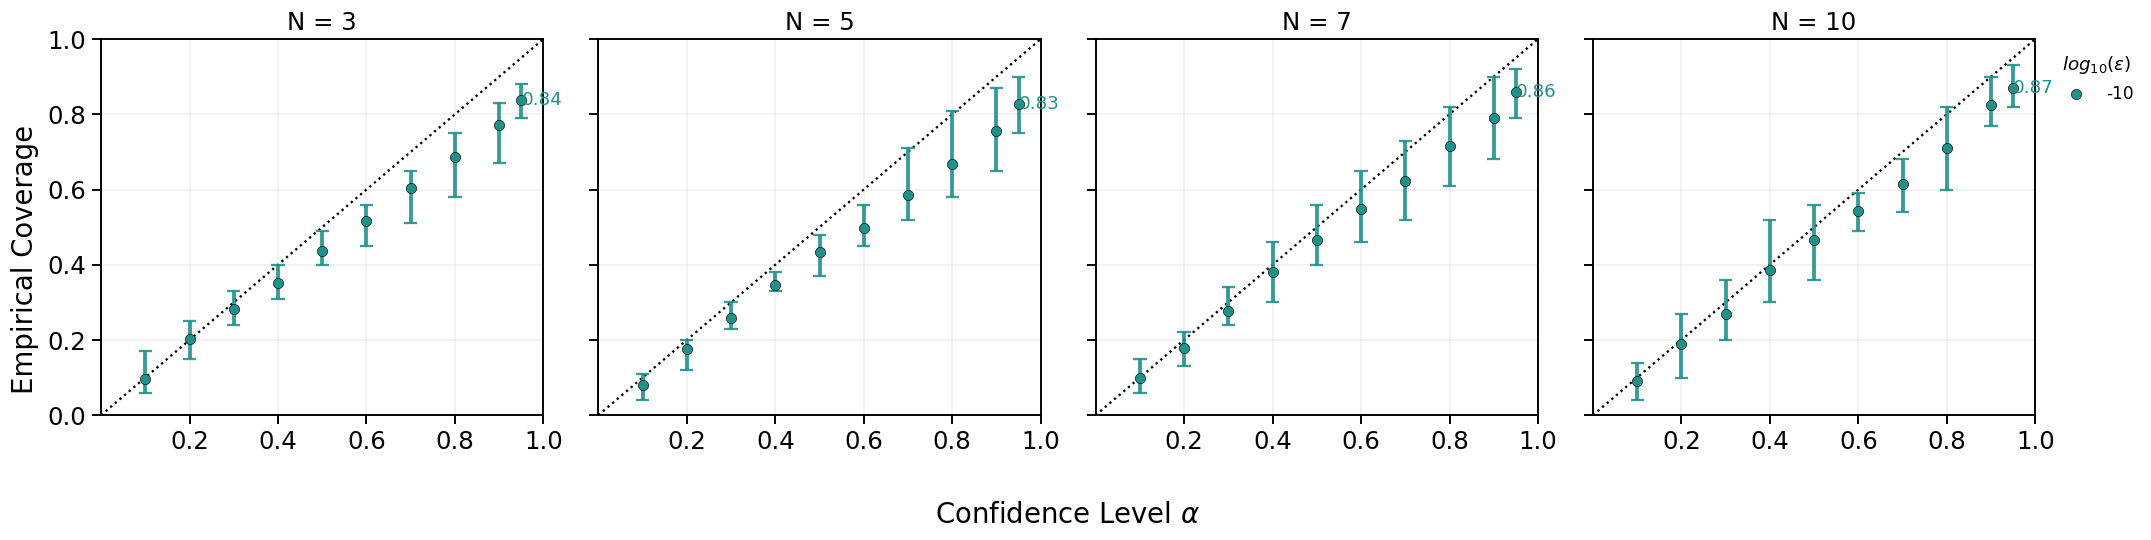

In [17]:
change_font(16)
# change epsilon grid to [0,-10,-100,-1000] only for the coverage curves plot, not the previous ones
COV_EPSILON_GRID = [-10]

def coverage_mean_and_range(covs):
    per_param_curve = covs.float().mean(dim=0)
    mean_curve = per_param_curve.mean(dim=1)
    lower = per_param_curve.min(dim=1).values
    upper = per_param_curve.max(dim=1).values
    return mean_curve.cpu().numpy(), lower.cpu().numpy(), upper.cpu().numpy()

missing_keys = [
    (int(n_reps), float(epsilon))
    for n_reps in N_REPS_LIST
    for epsilon in COV_EPSILON_GRID
    if (int(n_reps), float(epsilon)) not in cache
]
if missing_keys:
    raise KeyError(f'Missing cached sweep results for {missing_keys}. Run the sweep cell first.')

fig, axes = plt.subplots(1, len(N_REPS_LIST), figsize=(5 * len(N_REPS_LIST), 5), sharex=True, sharey=True, tight_layout=True)
if len(N_REPS_LIST) == 1:
    axes = [axes]

palette = sns.color_palette('viridis', n_colors=len(COV_EPSILON_GRID))
conf_levels = CONF_LEVELS.numpy()
cap_width = 0.015

for ax, n_reps in zip(axes, N_REPS_LIST):
    ax.plot(np.linspace(0, 1, 100), np.linspace(0, 1, 100), color='black', ls=':', lw=1.5)
    for color, epsilon in zip(palette, COV_EPSILON_GRID):
        result = cache[(int(n_reps), float(epsilon))]
        mean_curve, lower, upper = coverage_mean_and_range(result['covs'])
        ax.vlines(conf_levels, lower, upper, color=color, lw=2.5, alpha=0.9)
        ax.hlines(lower, conf_levels - cap_width, conf_levels + cap_width, color=color, lw=1.5, alpha=0.9)
        ax.hlines(upper, conf_levels - cap_width, conf_levels + cap_width, color=color, lw=1.5, alpha=0.9)
        ax.scatter(
            conf_levels,
            mean_curve,
            color=color,
            edgecolor='black',
            linewidth=0.4,
            s=45,
            zorder=3,
            label=f'{epsilon:g}',
        )
        ax.text(CONF_LEVELS[-1].item(), mean_curve[-1], f'{mean_curve[-1]:.2f}', color=color, fontsize=12, va='center', ha='left')
    ax.set_title(f'N = {n_reps}', fontsize=16)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks(np.arange(0.2, 1.1, 0.2))
    ax.grid(alpha=0.2)

fig.supxlabel(r'Confidence Level $\alpha$', fontsize=18)
fig.supylabel('Empirical Coverage', fontsize=18)
axes[-1].legend(title=r'$log_{10}(\varepsilon)$', frameon=False, bbox_to_anchor=(1.02, 1), loc='upper left')
fig.savefig(BASE / 'epsilon_vs_N_coverage_curves.png', dpi=300, bbox_inches='tight')
plt.show()


In [30]:
result = cache[10,-10.0]
result['coverage_curve_per_param'][-1,:]

tensor([0.8300, 0.9300, 0.8300, 0.8800, 0.8200, 0.9300])